## Imports ##

In [12]:
import numpy as np
import scipy.constants
import matplotlib.pyplot as plt

## Calculating Ice Strain Rate (Figure 5) ##

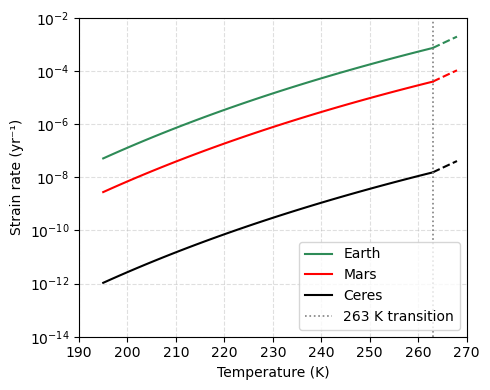

In [18]:
YR_2_SEC = 86400*365.25 # Convert years to seconds

n = 3 # Glen's law stress exponent
rho_ice = 917 # kg/m^3
h = 4.5 # m, height of dome
g_earth = 9.81 # m/s^2, gravity on Earth
g_mars = 3.71 # m/s^2, gravity on Mars
g_ceres = 0.27 # m/s^2, gravity on Ceres

stress = lambda g: rho_ice * h * g # calculate stress from hydrostatic pressure

R = scipy.constants.R # universal gas constant

q_cold = 60000 # J/mol, T < 263 K, cuffey & paterson 2010
q_warm = 115000 # J/mol, T > 263 K, cuffey & paterson 2010

T_o = 195 # beginning temperature (K)
T_transition = 263.0 # reference temperature (K)

# Temperature ranges based on Paterson 2006
T_cold = np.linspace(T_o, T_transition, 40) # temperature before Q change at 263 K
T_warm = np.linspace(T_transition, 268, 15) # temperature before Q change at 263 K

a_at_transition = 3.5e-25 # prefactor A_* value at 10 K

a = lambda q, T: a_at_transition * np.exp(-q / R * (1/T - 1/T_transition)) # equation for A as a function of T

# Combined plot
fig, ax = plt.subplots(figsize=(5, 4))

# Earth
ax.plot(T_cold, a(q_cold,T_cold) * stress(g_earth)**n * YR_2_SEC, color='seagreen', label='Earth') # Plotting Earth strain rate case for cold temperatures
ax.plot(T_warm, a(q_warm,T_warm) * stress(g_earth)**n * YR_2_SEC, color='seagreen',linestyle='--') # Plotting Earth strain rate case for warm temperatures

# Mars
ax.plot(T_cold, a(q_cold,T_cold) * stress(g_mars)**n * YR_2_SEC, color='red', label='Mars') # Plotting Mars strain rate case for cold temperatures
ax.plot(T_warm, a(q_warm,T_warm) * stress(g_mars)**n * YR_2_SEC, color='red',linestyle='--') # Plotting Mars strain rate case for warm temperatures

# Ceres
ax.plot(T_cold, a(q_cold,T_cold) * stress(g_ceres)**n * YR_2_SEC, color='black', label='Ceres') # Plotting Ceres strain rate case for cold temperatures
ax.plot(T_warm, a(q_warm,T_warm) * stress(g_ceres)**n * YR_2_SEC, color='black',linestyle='--') # Plotting Ceres strain rate case for warm temperatures

# Mark the transition
ax.axvline(T_transition, color='gray', linestyle=':', linewidth=1.2, label='263 K transition')

ax.set_yscale('log')
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Strain rate (yr⁻¹)")
ax.set_xlim([190,270])
ax.set_ylim([1e-14,1e-2])
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()